In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna
from sklearn.metrics import accuracy_score

C:\Users\DELL\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("online_shoppers_intention.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [4]:
df.duplicated().sum()

np.int64(125)

In [5]:
df = df.drop_duplicates()

In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12205 non-nul

In [9]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [10]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [11]:
X_train_full , X_test,y_train_full,y_test = train_test_split(X,y,test_size=0.2,random_state=21,stratify=y)

In [12]:
X_train,X_val,y_train,y_val = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=21,stratify=y_train_full)

In [13]:
num_cols = X.select_dtypes(exclude = "object").columns
cat_cols = X.select_dtypes(include = "object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_24272\1635958761.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include = "object").columns


In [14]:
preprocessor = ColumnTransformer([("Scaling",MinMaxScaler(),num_cols),
                                  ("Encoding",OneHotEncoder(drop = "first",handle_unknown="ignore"),cat_cols)],
                                 remainder = "drop")

In [15]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

In [16]:
model = Sequential([Input(shape=(X_train_t.shape[1],)),
                    Dense(32,activation="relu"),
                    Dense(64,activation="relu"),
                    Dense(1,activation="sigmoid")])

In [36]:
model.compile(optimizer="Adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [37]:
early = EarlyStopping(monitor = "val_loss",patience = 5 , restore_best_weights=True)

In [38]:
model.fit(X_train_t,y_train,
          epochs = 50,
          validation_data=(X_val_t,y_val),
          batch_size=256,
          callbacks=[early],
          verbose = 2)

Epoch 1/50
31/31 - 6s - 180ms/step - accuracy: 0.5803 - loss: 2.9052 - val_accuracy: 0.5535 - val_loss: 2.7198
Epoch 2/50
31/31 - 0s - 12ms/step - accuracy: 0.7045 - loss: 2.4955 - val_accuracy: 0.7358 - val_loss: 2.3899
Epoch 3/50
31/31 - 0s - 13ms/step - accuracy: 0.7706 - loss: 2.1915 - val_accuracy: 0.8203 - val_loss: 2.0992
Epoch 4/50
31/31 - 0s - 13ms/step - accuracy: 0.8077 - loss: 1.9247 - val_accuracy: 0.8428 - val_loss: 1.8452
Epoch 5/50
31/31 - 0s - 13ms/step - accuracy: 0.8340 - loss: 1.6967 - val_accuracy: 0.8541 - val_loss: 1.6264
Epoch 6/50
31/31 - 0s - 12ms/step - accuracy: 0.8356 - loss: 1.5125 - val_accuracy: 0.8520 - val_loss: 1.4478
Epoch 7/50
31/31 - 0s - 13ms/step - accuracy: 0.8457 - loss: 1.3401 - val_accuracy: 0.8546 - val_loss: 1.3007
Epoch 8/50
31/31 - 0s - 13ms/step - accuracy: 0.8464 - loss: 1.2004 - val_accuracy: 0.8571 - val_loss: 1.1613
Epoch 9/50
31/31 - 0s - 12ms/step - accuracy: 0.8548 - loss: 1.0762 - val_accuracy: 0.8566 - val_loss: 1.0431
Epoch 10/

In [39]:
y_pred = np.where(model.predict(X_test_t)>0.5,1,0)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [40]:
accuracy_score(y_pred,y_test)

0.8951249487914789

In [41]:
smote = SMOTE()
X_train_res,y_train_res = smote.fit_resample(X_train_t,y_train)

In [44]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1 = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg = trial.suggest_float(f'reg{i}', 1e-5, 1e-4, log=True)
        model.add(Dense(units, activation=activation, kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam': Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD': SGD(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [45]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)  

[I 2026-06-28 17:11:31,011] A new study created in memory with name: no-name-3408b0f3-a68e-4600-86e9-0c9bb4787331
Best trial: 0. Best value: 0.714754:  20%|█████████▍                                     | 1/5 [00:17<01:09, 17.26s/it]

[I 2026-06-28 17:11:48,267] Trial 0 finished with value: 0.7147541046142578 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 3.1327774916988765e-05, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 9.342973678849743e-05}. Best is trial 0 with value: 0.7147541046142578.


Best trial: 1. Best value: 0.92459:  40%|███████████████████▏                            | 2/5 [00:34<00:52, 17.52s/it]

[I 2026-06-28 17:12:05,967] Trial 1 finished with value: 0.9245901703834534 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 3.502421090809937e-05, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 5.329475245136149e-05}. Best is trial 1 with value: 0.9245901703834534.


Best trial: 2. Best value: 0.960656:  60%|████████████████████████████▏                  | 3/5 [00:46<00:29, 14.74s/it]

[I 2026-06-28 17:12:17,406] Trial 2 finished with value: 0.9606557488441467 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 64, 'units0': 78, 'dropout0': 0.4438277186036015, 'reg0': 4.9987427695191384e-05, 'units1': 48, 'dropout1': 0.15295758239442775, 'reg1': 6.608218659434467e-05}. Best is trial 2 with value: 0.9606557488441467.


Best trial: 2. Best value: 0.960656:  80%|█████████████████████████████████████▌         | 4/5 [00:51<00:11, 11.06s/it]

[I 2026-06-28 17:12:22,811] Trial 3 finished with value: 0.7016393542289734 and parameters: {'learning_rate': 0.00019025203500883987, 'n_layers': 2, 'optimizer': 'SGD', 'activation': 'relu', 'batch_size': 256, 'units0': 73, 'dropout0': 0.23032323416126815, 'reg0': 7.312834579957106e-05, 'units1': 70, 'dropout1': 0.08398753671647846, 'reg1': 1.5109374061559687e-05}. Best is trial 2 with value: 0.9606557488441467.


Best trial: 2. Best value: 0.960656: 100%|███████████████████████████████████████████████| 5/5 [01:14<00:00, 14.96s/it]

[I 2026-06-28 17:12:45,806] Trial 4 finished with value: 0.8393442630767822 and parameters: {'learning_rate': 0.005009680824617574, 'n_layers': 2, 'optimizer': 'SGD', 'activation': 'relu', 'batch_size': 64, 'units0': 58, 'dropout0': 0.2555683582705914, 'reg0': 3.381250204700588e-05, 'units1': 54, 'dropout1': 0.4659387787965033, 'reg1': 1.7643142181691744e-05}. Best is trial 2 with value: 0.9606557488441467.


In [46]:
study.best_params

{'learning_rate': 0.004995574347086988,
 'n_layers': 2,
 'optimizer': 'RMSprop',
 'activation': 'relu',
 'batch_size': 64,
 'units0': 78,
 'dropout0': 0.4438277186036015,
 'reg0': 4.9987427695191384e-05,
 'units1': 48,
 'dropout1': 0.15295758239442775,
 'reg1': 6.608218659434467e-05}

In [47]:
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train_res.shape[1],)))

# 1st Hidden Layer
model.add(Dense(73,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=4.9987427695191384e-05,l2=4.9987427695191384e-05)))
model.add(BatchNormalization())
model.add(Dropout(0.4438277186036015))

# 2nd Hidden Layer
model.add(Dense(70,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=6.608218659434467e-05,l2=6.608218659434467e-05)))
model.add(BatchNormalization())
model.add(Dropout(0.15295758239442775))

# Output Layer-
model.add(Dense(1, activation='sigmoid', kernel_initializer="glorot_uniform"))


In [48]:
model.compile(optimizer=RMSprop(learning_rate=0.004995574347086988), loss='binary_crossentropy',
                  metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [49]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [50]:
history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=64,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )

In [51]:
y_pred=np.where(model.predict(X_test_t)>0.5,1,0)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [52]:
accuracy_score(y_pred,y_test)

0.5497746825071692

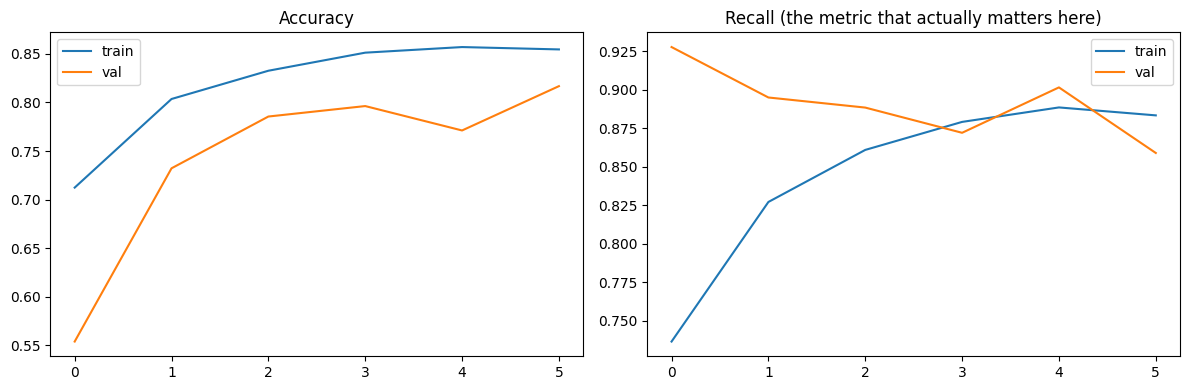

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['recall'], label='train')
axes[1].plot(history.history['val_recall'], label='val')
axes[1].set_title('Recall (the metric that actually matters here)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [54]:
# Training accuracy
y_pred_train = np.where(model.predict(X_train_res) > 0.5, 1, 0)
train_acc = accuracy_score(y_train_res, y_pred_train)

# Validation accuracy
y_pred_val = np.where(model.predict(X_val_t) > 0.5, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

# Test accuracy
y_pred_test = np.where(model.predict(X_test_t) > 0.5, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Train Accuracy      : 0.7285
Validation Accuracy : 0.5540
Test Accuracy       : 0.5498


In [55]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

       False       0.98      0.48      0.64      2059
        True       0.25      0.94      0.40       382

    accuracy                           0.55      2441
   macro avg       0.61      0.71      0.52      2441
weighted avg       0.86      0.55      0.60      2441

